# H1 Aumento sostenido de las temperaturas

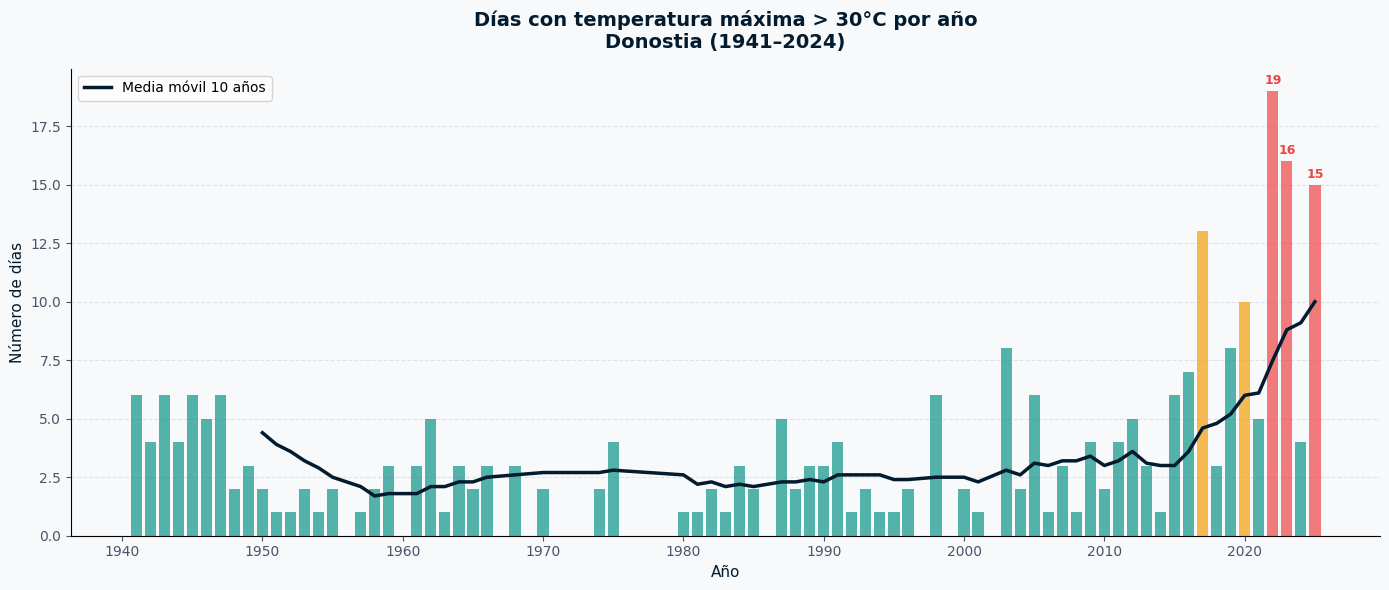

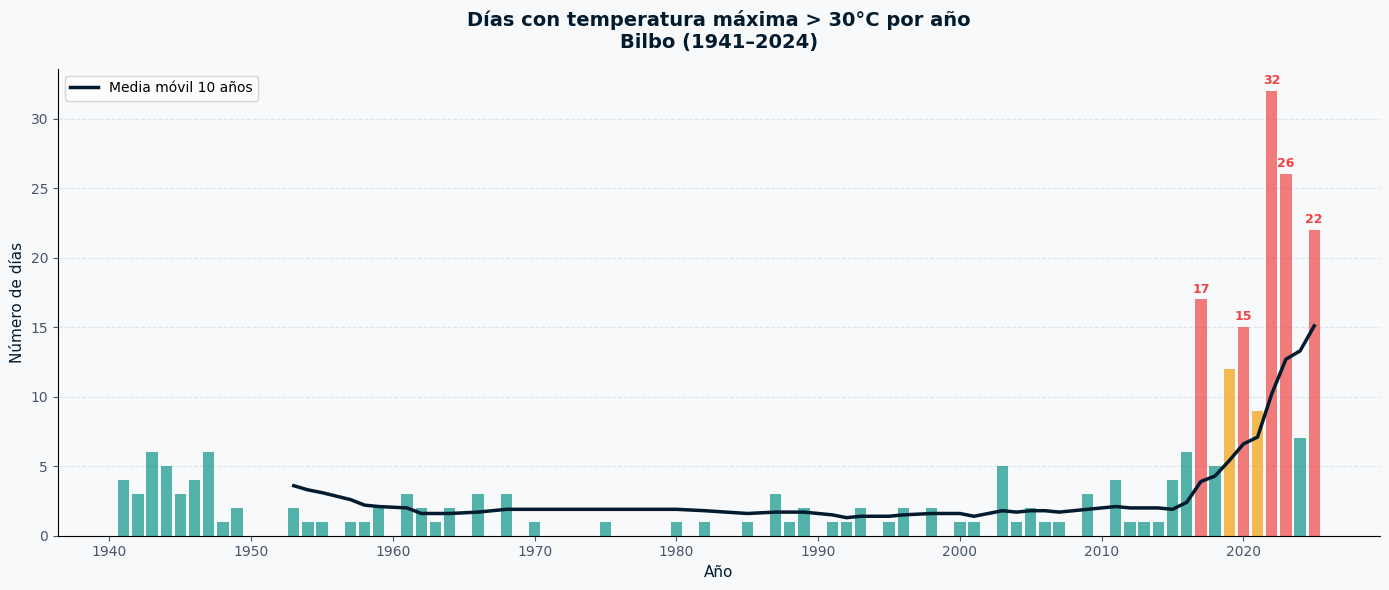

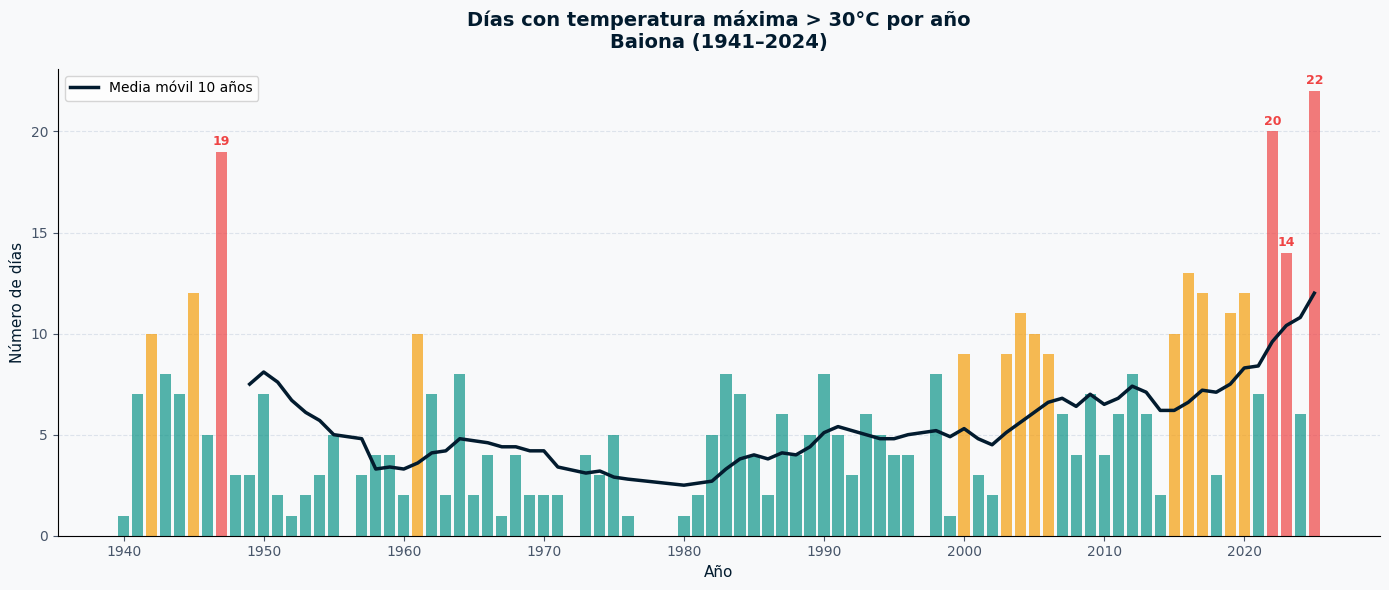

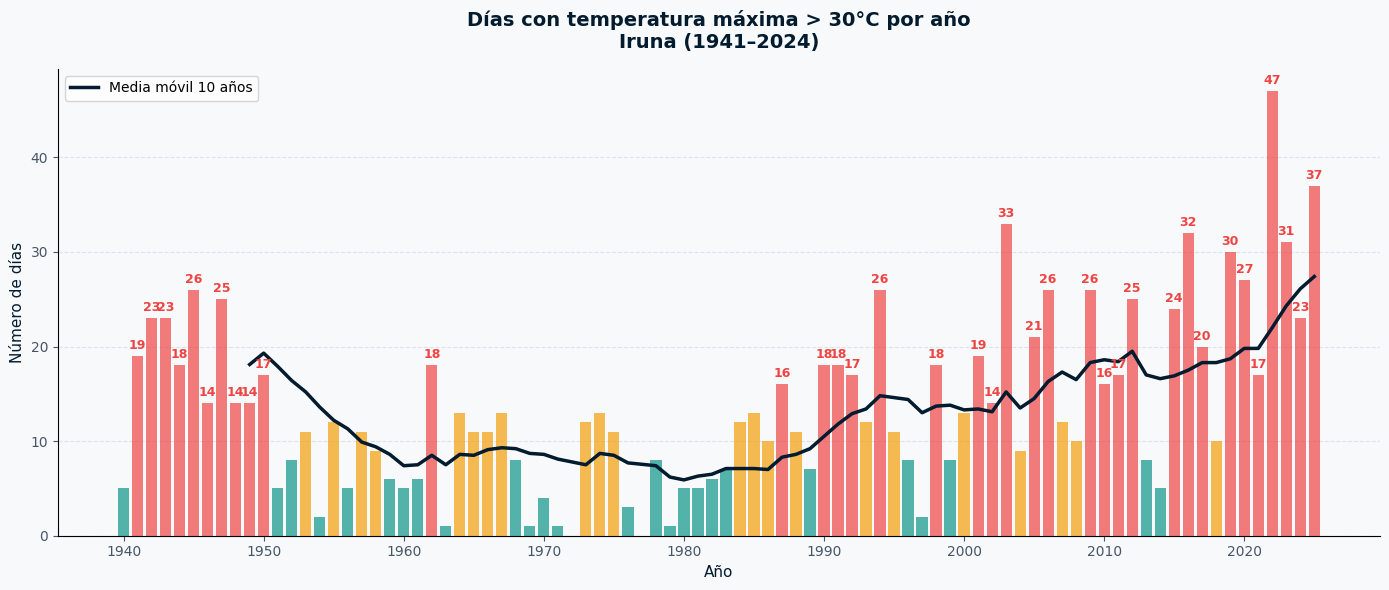

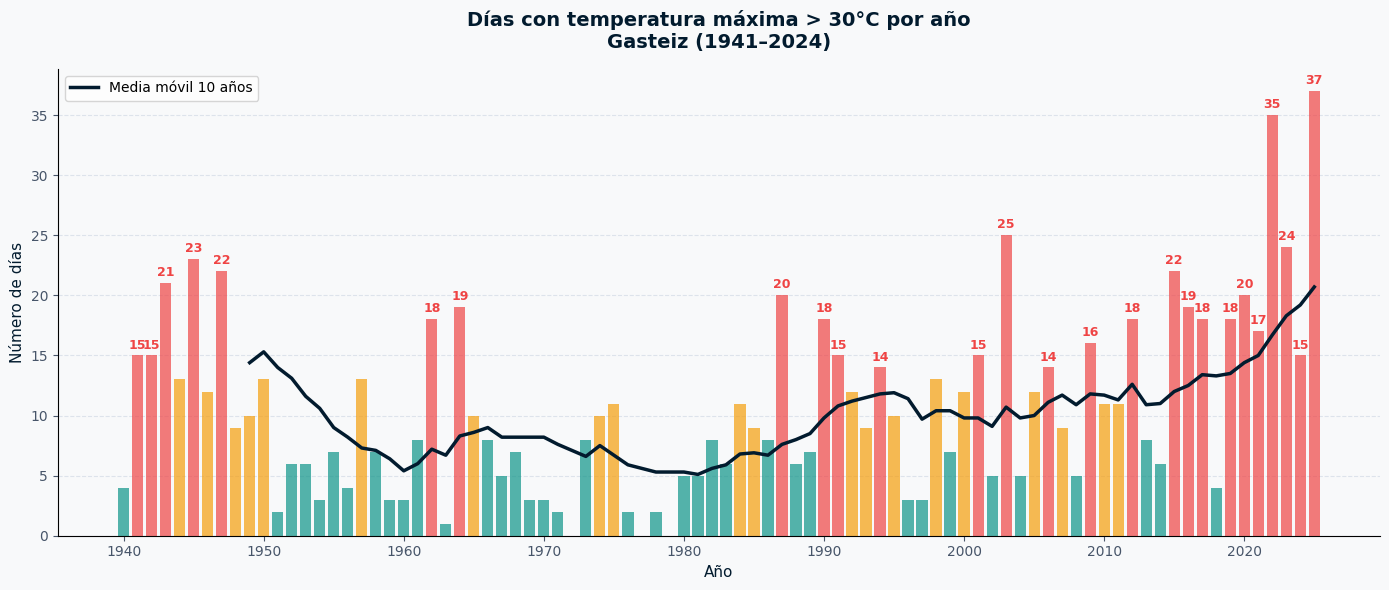

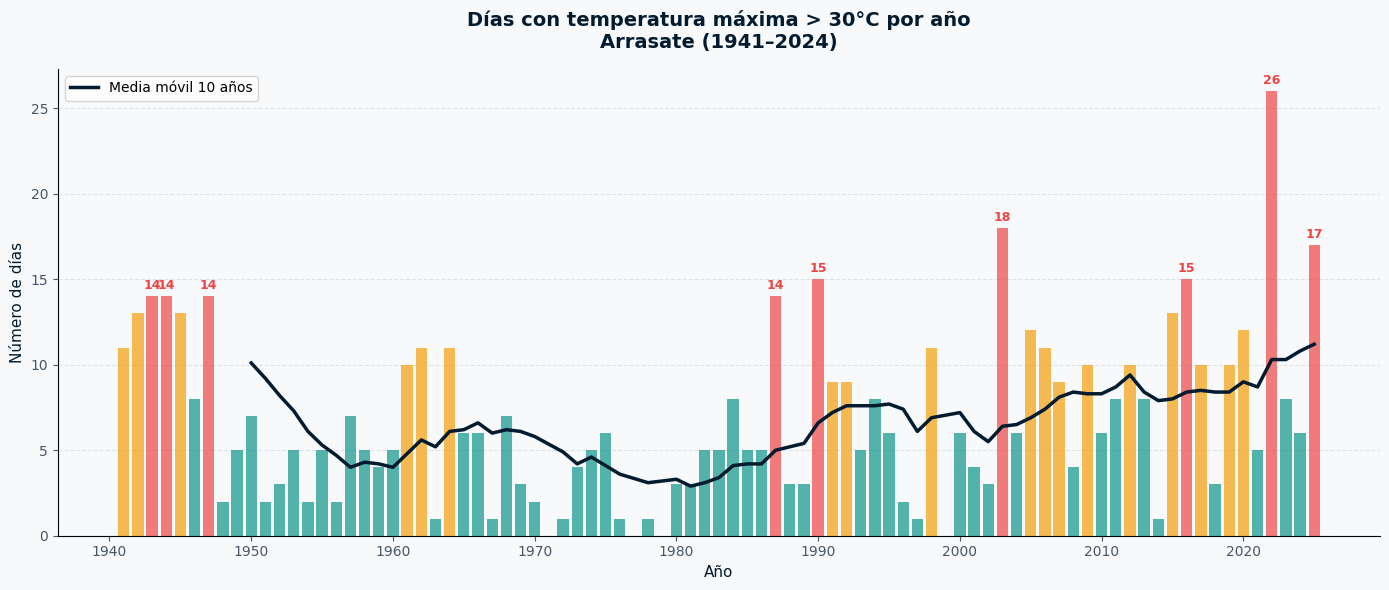

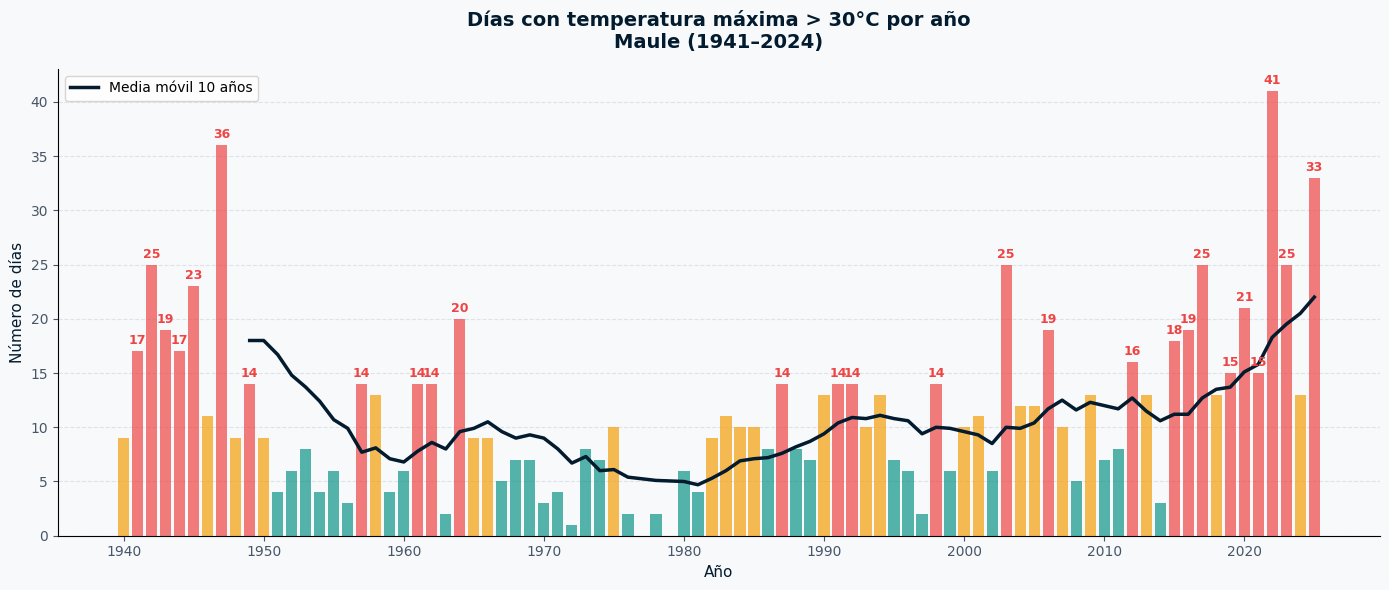

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np   
from utils.variables import csv_list, dfs
from utils.funciones import cargar_datos

# Calculo mensual de la temperatura maxima, mínima y media para cada ciudad...

# Cargar datos
cargar_datos(csv_list)

for csv_name in dfs:
    df = dfs[csv_name]  # Get the dataframe properly
    
    # Temperaturas mayores a los 30 grados
    df_max_30 = df[df['temperature_2m_max'] > 30].groupby('año').size()

    # ── Datos ──────────────────────────────────────────────────
    años = df_max_30.index.tolist()   # toma los años directamente de tu Serie
    dias = df_max_30.values

    # ── Media móvil ────────────────────────────────────────────
    window = 10
    media_movil = np.convolve(dias, np.ones(window)/window, mode='valid')
    años_mm = años[window-1:]

    # ── Figura ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#F8F9FA')
    ax.set_facecolor('#F8F9FA')

    # Barras coloreadas por valor
    colors = ['#0D9488' if d <= 8 else '#F59E0B' if d <= 13 else '#EF4444' for d in dias]
    ax.bar(años, dias, color=colors, alpha=0.7, width=0.8, zorder=2)

    # Media móvil
    ax.plot(años_mm, media_movil, color='#021B2E', linewidth=2.5,
            label=f'Media móvil {window} años', zorder=3)

    # ── Estilo ─────────────────────────────────────────────────
    ax.set_title(f'Días con temperatura máxima > 30°C por año\n{csv_name.capitalize()} (1941–2024)',
            fontsize=14, fontweight='bold', color='#021B2E', pad=15)
    ax.set_xlabel('Año', fontsize=11, color='#021B2E')
    ax.set_ylabel('Número de días', fontsize=11, color='#021B2E')  # FIXED: removed extra 'a'
    ax.tick_params(colors='#475569')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.grid(axis='y', color='#CBD5E1', linestyle='--', alpha=0.6, zorder=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10)

    # Anotar años destacados (>= 14 días)
    for año, dia in zip(años, dias):
        if dia >= 14:
            ax.annotate(f'{dia}', xy=(año, dia), xytext=(0, 5),
                        textcoords='offset points', ha='center',
                        fontsize=9, color='#EF4444', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'img/temp_30/grafico_dias_30_{csv_name}.png', dpi=180, bbox_inches='tight')
    plt.show()